In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
import nltk
from  bs4 import BeautifulSoup
import streamlit as st
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from nltk.corpus import stopwords
from imblearn.over_sampling import SMOTE
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import(accuracy_score,precision_score,f1_score,recall_score,confusion_matrix,classification_report)
import joblib
import streamlit as st
nltk.download("stopworda")
nltk.download("wordnet")

[nltk_data] Error loading stopworda: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [2]:
df=pd.read_csv("IMDB_dataset-2.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


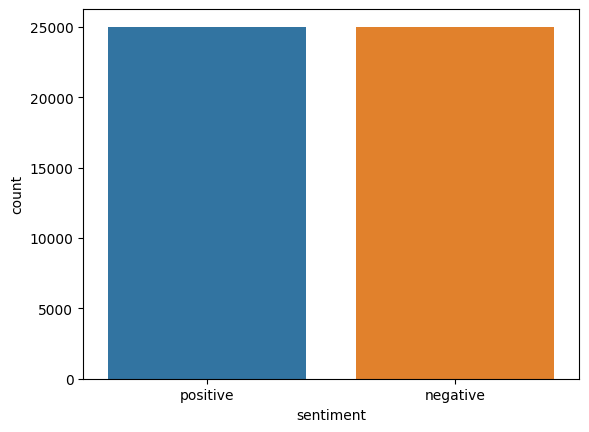

In [7]:
sns.countplot(x="sentiment",data=df)
plt.show()

In [8]:
df.duplicated().sum()

418

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

0

In [11]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [12]:
stop_words=(stopwords.words("english"))
lemmatizer=WordNetLemmatizer()
def clean_text(text):
    text=str(text)
    text=BeautifulSoup(text,"html.parser").get_text()
    text=re.sub(r"https\S+|www\S+|http\S+","",text)
    text=re.sub(r"[^a-zA-Z\s]","",text)
    text=re.sub(r"@\w+","",text)
    text=re.sub(r"\d+","",text)
    text=re.sub(r"\s+","",text).strip()
    text=text.lower()
    words=text.split()
    words=[lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return" ".join(words)
    

In [13]:
df["clean_df"] = df["review"].apply(clean_text)

In [14]:
df["clean_df"].head()

0    oneoftheotherreviewershasmentionedthatafterwat...
1    awonderfullittleproductionthefilmingtechniquei...
2    ithoughtthiswasawonderfulwaytospendtimeonatooh...
3    basicallytheresafamilywherealittleboyjakethink...
4    pettermatteisloveinthetimeofmoneyisavisuallyst...
Name: clean_df, dtype: object

In [15]:
df["sentiment"].value_counts()

positive    24884
negative    24698
Name: sentiment, dtype: int64

In [16]:
x=df["review"]
y=df["sentiment"].map({"positive":1,"negative":0})

In [17]:
y.isnull().sum()

0

In [18]:
most_frequent=y.mode()[0]
y=y.fillna(most_frequent)

In [19]:
y.isnull().sum()

0

In [20]:
print(df["sentiment"].unique())

['positive' 'negative']


In [21]:
# def clean_text_pipeline(text):
#     return[clean_text(text) for text in text]

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [23]:
model_lg=Pipeline(steps=[
    ("tfidf",TfidfVectorizer(max_features=20000,ngram_range=(1,2),min_df=2,stop_words="english")),
    ("clf",LogisticRegression(max_iter=2000,C=0.1))
])

In [24]:
model_lg.fit(x_train,y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, min_df=2,
                                 ngram_range=(1, 2), stop_words='english')),
                ('clf', LogisticRegression(C=0.1, max_iter=2000))])

In [25]:
y_pred_lg=model_lg.predict(x_test)

In [26]:
accuracy_lg=accuracy_score(y_test,y_pred_lg)
precision_lg=precision_score(y_test,y_pred_lg)
recall_lg=recall_score(y_test,y_pred_lg)
f1_score_lg=f1_score(y_test,y_pred_lg)
print("Accuracy:- ",accuracy_lg)
print("Precision:- ",precision_lg)
print("Recall:- ",recall_lg)
print("F1_score:- ",f1_score_lg)


Accuracy:-  0.8732479580518302
Precision:-  0.8513411409142425
Recall:-  0.9055656017681334
F1_score:-  0.8776165904001557


In [27]:
confusion_lg=confusion_matrix(y_test,y_pred_lg)
print("Confusion-: ",confusion_lg)

Confusion-:  [[4153  787]
 [ 470 4507]]


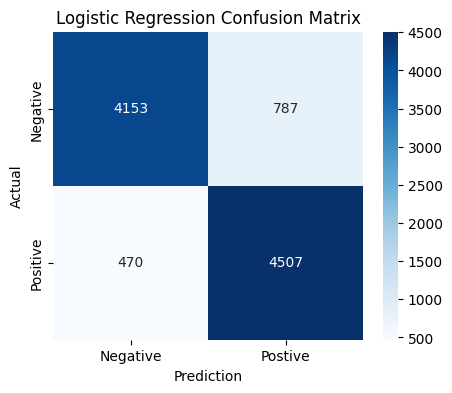

In [28]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_lg,annot=True,fmt="d",cmap="Blues",xticklabels=["Negative","Postive"],yticklabels=["Negative","Positive"])
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [29]:
cr_lg=classification_report(y_test,y_pred_lg)
print("Classifivation report",cr_lg)

Classifivation report               precision    recall  f1-score   support

           0       0.90      0.84      0.87      4940
           1       0.85      0.91      0.88      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



In [30]:
model_NB=Pipeline(steps=[
    ("tfidf",TfidfVectorizer(max_features=20000,ngram_range=(1,2),stop_words="english")),
    ("clf",MultinomialNB(alpha=0.1))
])

In [31]:
model_NB.fit(x_train,y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf', MultinomialNB(alpha=0.1))])

In [32]:
y_pred_NB=model_NB.predict(x_test)

In [33]:
accuracy_NB=accuracy_score(y_test,y_pred_NB)
precision_NB=precision_score(y_test,y_pred_NB)
recall_NB=recall_score(y_test,y_pred_NB)
f1_score_NB=f1_score(y_test,y_pred_NB)
print("Accuracy score:- ",accuracy_NB)
print("Precision score:- ",precision_NB)
print("Recall_NB:- ",recall_NB)
print("F1_score:- ",f1_score_NB)

Accuracy score:-  0.8702228496521125
Precision score:-  0.8626179245283019
Recall_NB:-  0.8818565400843882
F1_score:-  0.8721311475409838


In [34]:
cm_NB=confusion_matrix(y_test,y_pred_NB)
print("Confusion matrix:- ",cm_NB)

Confusion matrix:-  [[4241  699]
 [ 588 4389]]


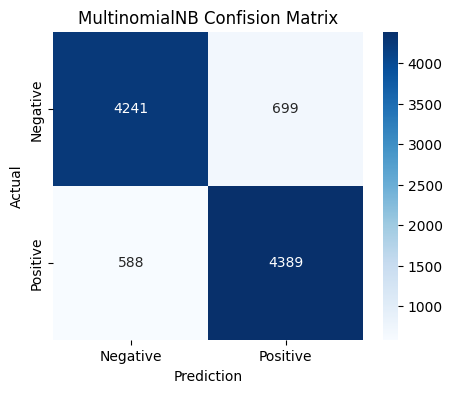

In [35]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_NB,annot=True,cmap="Blues",fmt="d",xticklabels=["Negative","Positive"],yticklabels=["Negative","Positive"])
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("MultinomialNB Confision Matrix")
plt.show()

In [36]:
cr_NB=classification_report(y_test,y_pred_NB)
print(cr_NB)

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      4940
           1       0.86      0.88      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



In [37]:
model_svm=Pipeline(steps=[
    ("tfidv",TfidfVectorizer(max_features=20000,ngram_range=(1,2))),
    ("clf",LinearSVC())
])

In [38]:
model_svm.fit(x_train,y_train)

Pipeline(steps=[('tfidv',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
                ('clf', LinearSVC())])

In [39]:
y_pred_svm=model_svm.predict(x_test)

In [40]:
accuracy_svm=accuracy_score(y_test,y_pred_svm)
precision_svm=precision_score(y_test,y_pred_svm)
recall_svm=recall_score(y_test,y_pred_svm)
f1_score_svm=f1_score(y_test,y_pred_svm)
print("Accuracy score:- ",accuracy_svm)
print("Precision score:- ",precision_svm)
print("Recall Score:- ",recall_svm)
print("F1 Score",f1_score_svm)

Accuracy score:-  0.9006756075426036
Precision score:-  0.8941548183254344
Recall Score:-  0.9097850110508339
F1 Score 0.9019022009759984


In [41]:
cm_svm=confusion_matrix(y_test,y_pred_svm)
print(cm_svm)

[[4404  536]
 [ 449 4528]]


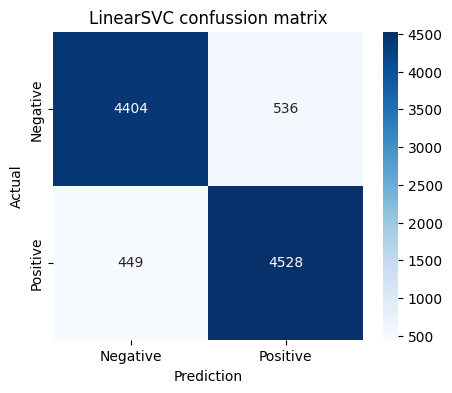

In [42]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm,annot=True,cmap="Blues",fmt="d",xticklabels=["Negative","Positive"],yticklabels=["Negative","Positive"])
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("LinearSVC confussion matrix")
plt.show()

In [47]:
model_rfc=Pipeline(steps=[
    ("tfidf",TfidfVectorizer(max_features=20000,ngram_range=(1,2),stop_words=("english"))),
    ("clf",RandomForestClassifier(n_estimators=200,max_depth=10,min_samples_split=5,min_samples_leaf=2,max_features="sqrt"))
])

In [48]:
model_rfc.fit(x_train,y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=2,
                                        min_samples_split=5,
                                        n_estimators=200))])

In [55]:
y_pred_rfc=model_rfc.predict(x_test)

In [56]:
accuracy_rfc=accuracy_score(y_test,y_pred_rfc)
precision_rfc=precision_score(y_test,y_pred_rfc)
recall_rfc=recall_score(y_test,y_pred_rfc)
f1_score_rfc=f1_score(y_test,y_pred_rfc)
print("Accuracy score:- ",accuracy_rfc)
print("Precision score:- ",precision_rfc)
print("Recall Score:- ",recall_rfc)
print("F1 Score",f1_score_rfc)

Accuracy score:-  0.8275688212160935
Precision score:-  0.7879428873611846
Recall Score:-  0.8981314044605184
F1 Score 0.83943661971831


In [57]:
cm_rfc=confusion_matrix(y_test,y_pred_rfc)
print(cm_rfc)

[[3737 1203]
 [ 507 4470]]


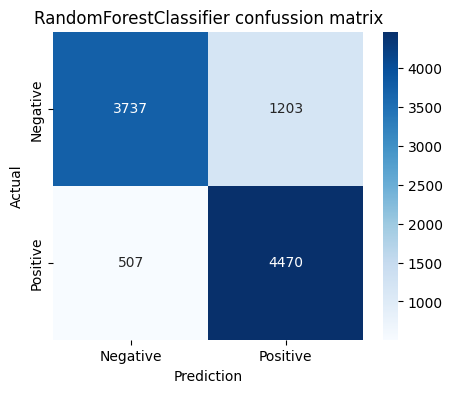

In [59]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_rfc,annot=True,cmap="Blues",fmt="d",xticklabels=["Negative","Positive"],yticklabels=["Negative","Positive"])
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("RandomForestClassifier confussion matrix")
plt.show()

In [60]:
lr_train=model_lg.score(x_train,y_train)
lr_test=model_lg.score(x_test,y_test)

nb_train=model_NB.score(x_train,y_train)
nb_test=model_NB.score(x_test,y_test)

svm_train=model_svm.score(x_train,y_train)
svm_test=model_svm.score(x_test,y_test)

rfc_train=model_rfc.score(x_train,y_train)
rfc_test=model_rfc.score(x_test,y_test)

In [61]:
results=pd.DataFrame({
    "Model":["Logistic Regression",
            "MultinomialNB",
            "LinearSVC",
            "RandomForestClassifier"],
    "Train Accuracy":[lr_train,nb_train,svm_train,rfc_train],
    "Test Accuracy":[lr_test,nb_test,svm_test,rfc_test]
})
print(results.sort_values(by="Test Accuracy",ascending=False))

                    Model  Train Accuracy  Test Accuracy
2               LinearSVC        0.983487       0.900676
0     Logistic Regression        0.883247       0.873248
1           MultinomialNB        0.891491       0.870223
3  RandomForestClassifier        0.849616       0.827569


In [63]:
joblib.dump(model_svm,"imdb_sentiment_model.joblib")

['imdb_sentiment_model.joblib']

In [68]:
%%writefile app_5.py
import streamlit as st
import joblib
model=joblib.load("imdb_sentiment_model.joblib")
st.title("IMDB Sentiment Analysis")
review=st.text_area("Enter movie review")
if st.button("Predict"):
    prediction=model.predict([review])[0]
    if prediction == 1:
        st.success("Positive review")
    else:
        st.error("Negative review")

Overwriting app_5.py


In [69]:
%%writefile requirements.txt
streamlit
pandas
numpy
sckit-learn
imbalanced-learn
joblib

Overwriting requirements.txt
